# Lattice Correspondence And Transformation Strain

[Notebook 18](18_orientation_relationships_fundamentals.ipynb) treated an orientation relationship as a *rotation*. This
notebook works through the other two pillars of the doctrine:

- the **index correspondence** — which parent planes and directions map
  onto which child planes and directions, exactly and with rationalized
  integer indices,
- the **deformation gradient** — the physical lattice distortion the
  transformation must supply, with its principal stretches and volume
  change.

## The mathematics

With $A_p$, $A_c$ the direct structure matrices (crystal basis vectors as
columns) and $R$ the OR rotation, the **direct correspondence** acting on
direction indices is

$$M = A_c^{-1} R\, A_p, \qquad u_c = M u_p ,$$

and plane (reciprocal) indices map by the inverse transpose,

$$M^{*} = M^{-\mathsf T}, \qquad h_c = M^{*} h_p ,$$

which preserves the zone law $h\cdot u$ exactly. PyTex rationalizes the
generally irrational images to nearest-primitive-integer indices with an
explicit **angular residual**, so "$(111)_\gamma \to (011)_\alpha$" always
comes with the number of degrees that statement is off by.

The **deformation gradient** uses the *nearest-integer lattice
correspondence* $M_{\mathrm{int}}$ (magnitudes carry the strain, so ray
rationalization would be wrong) and removes the rigid rotation:

$$F = R^{\mathsf T} A_c M_{\mathrm{int}} A_p^{-1}, \qquad
F = R_{\mathrm{polar}}\, U ,$$

with the symmetric right stretch $U$ giving principal stretches
$\eta_i$ and $\det F$ the volume ratio. For the Bain correspondence:

$$\eta_1 = \eta_2 = \sqrt{2}\,\frac{a_\alpha}{a_\gamma},\qquad
\eta_3 = \frac{a_\alpha}{a_\gamma},\qquad
\frac{V_\alpha}{V_\gamma} = 2\left(\frac{a_\alpha}{a_\gamma}\right)^{3}.$$

![Bain correspondence cells](../../_static/or/bain_correspondence_cells.svg)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pytex import (
    CrystalDirection,
    CrystalPlane,
    FrameDomain,
    Handedness,
    Lattice,
    MillerIndex,
    Orientation,
    OrientationRelationship,
    OrientationSet,
    Phase,
    ReferenceFrame,
    Rotation,
    SymmetrySpec,
    fit_orientation_relationship,
    intervariant_misorientation_angles_deg,
    intervariant_misorientations,
    map_plane_across_variants,
    or_deviation,
    plot_variant_pole_figure,
    select_variants,
    standard_fcc_bcc_relationships,
    variant_close_packed_groups,
    variant_pole_figure,
)


def make_or_context():
    """Austenite (fcc) and ferrite/martensite (bcc) phases + a specimen frame."""
    parent_frame = ReferenceFrame(
        "austenite_crystal", FrameDomain.CRYSTAL, ("a", "b", "c"), Handedness.RIGHT
    )
    child_frame = ReferenceFrame(
        "martensite_crystal", FrameDomain.CRYSTAL, ("a", "b", "c"), Handedness.RIGHT
    )
    specimen = ReferenceFrame(
        "specimen", FrameDomain.SPECIMEN, ("x", "y", "z"), Handedness.RIGHT
    )
    austenite = Phase(
        "austenite",
        lattice=Lattice(3.60, 3.60, 3.60, 90.0, 90.0, 90.0, crystal_frame=parent_frame),
        symmetry=SymmetrySpec.from_point_group("m-3m", reference_frame=parent_frame),
        crystal_frame=parent_frame,
    )
    martensite = Phase(
        "martensite",
        lattice=Lattice(2.87, 2.87, 2.87, 90.0, 90.0, 90.0, crystal_frame=child_frame),
        symmetry=SymmetrySpec.from_point_group("m-3m", reference_frame=child_frame),
        crystal_frame=child_frame,
    )
    return austenite, martensite, specimen


In [2]:
austenite, martensite, specimen = make_or_context()
ks = OrientationRelationship.from_kurdjumov_sachs_correspondence(
    parent_phase=austenite, child_phase=martensite
)

mapped = ks.map_plane_to_child(
    CrystalPlane(MillerIndex(np.array([1, 1, 1]), phase=austenite),
                 phase=austenite)
)
print("KS defining plane map:", mapped.describe())

direction = ks.map_direction_to_child(
    CrystalDirection(np.array([-1.0, 0.0, 1.0]), phase=austenite)
)
print()
print("KS defining direction map:", direction.describe())


KS defining plane map: Plane correspondence: parent (111) maps to exact child components (-0.0000 0.9764 0.9764), rationalized to (011) with an angular residual of 0.0000 deg (angle between plane normals; indices in the target crystal reciprocal basis).

KS defining direction map: Direction correspondence: parent [-101] maps to exact child components [-1.0242 -1.0242 1.0242], rationalized to [-1-11] with an angular residual of 0.0000 deg (real-space angle; indices in the target crystal direct basis).


Across all 24 KS variants the same parent plane lands on different child
planes — only the six variants of its packet map (111) onto a {011}
child plane exactly; the other eighteen produce irrational images. The
angular residual makes that difference quantitative:


In [3]:
images = map_plane_across_variants(
    ks,
    CrystalPlane(MillerIndex(np.array([1, 1, 1]), phase=austenite),
                 phase=austenite),
)
residuals = np.array([image.angular_residual_deg for image in images])
exact = np.flatnonzero(residuals < 1e-9)
print(f"variants mapping (111) exactly onto {{011}}: {exact.size} "
      f"(variant indices {exact + 1})")
print(f"residuals of the other variants (deg): "
      f"{np.round(np.sort(residuals[residuals > 1e-9])[:5], 3)} ...")


variants mapping (111) exactly onto {011}: 6 (variant indices [ 1  3  6 15 20 24])
residuals of the other variants (deg): [0.365 0.365 0.365 0.365 0.365] ...


## The Bain strain, computed and rendered

`deformation_gradient()` turns the correspondence into physics. For the
pure Bain relationship the polar rotation is zero and the stretches are
the textbook values; KS, NW, and GT share the *same* stretches and
differ only in the rigid-body rotation riding on top.


In [4]:
bain = OrientationRelationship.from_bain_correspondence(
    parent_phase=austenite, child_phase=martensite
)
report = bain.deformation_gradient()
print(report.describe())

ratio = 2.87 / 3.60
print()
print(f"analytic check: sqrt(2)*a_a/a_g = {np.sqrt(2.0) * ratio:.6f}, "
      f"a_a/a_g = {ratio:.6f}, volume ratio = {2.0 * ratio**3:.6f}")


Transformation deformation for 'bain': principal strains +12.74%, +12.74%, -20.28% (principal directions in the parent crystal frame), volume change +1.34%. Integer lattice correspondence maps the parent basis to [1-10], [110], [001] (child indices; largest entry-wise deviation 0.254). Residual polar rotation 0.00 deg — zero for the pure correspondence distortion (Bain), and the rigid-body rotation relative to it for KS-class relationships.

analytic check: sqrt(2)*a_a/a_g = 1.127442, a_a/a_g = 0.797222, volume ratio = 1.013370


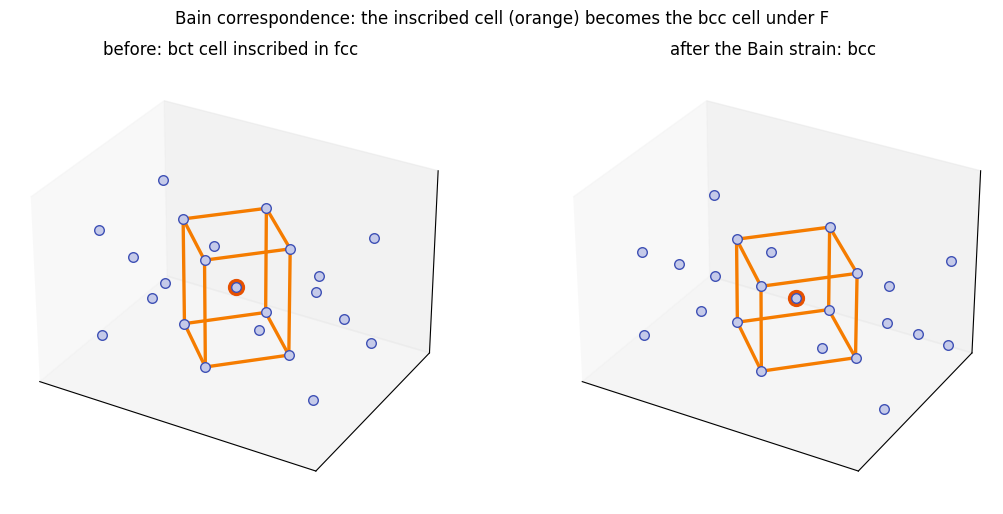

In [5]:
fig = plt.figure(figsize=(11.0, 5.2))

def draw_cell(ax, origin, edges, color, linewidth=2.4):
    for start, vector in edges:
        seg = np.stack([origin + start, origin + start + vector])
        ax.plot(seg[:, 0], seg[:, 1], seg[:, 2],
                color=color, linewidth=linewidth)

def cell_edges(a_vec, b_vec, c_vec):
    a_vec, b_vec, c_vec = (np.asarray(v, float)
                           for v in (a_vec, b_vec, c_vec))
    return [
        (np.zeros(3), a_vec), (np.zeros(3), b_vec), (np.zeros(3), c_vec),
        (a_vec, b_vec), (a_vec, c_vec),
        (b_vec, a_vec), (b_vec, c_vec),
        (c_vec, a_vec), (c_vec, b_vec),
        (a_vec + b_vec, c_vec), (a_vec + c_vec, b_vec),
        (b_vec + c_vec, a_vec),
    ]

a_g = 3.60
# fcc atoms of two cells (corners + face centers), parent frame, Angstrom
fcc = []
for x0 in (0.0, 1.0):
    for corner in np.ndindex(2, 2, 2):
        fcc.append((np.array([x0, 0, 0]) + np.array(corner)) * a_g)
    for center in ([x0 + .5, .5, 0], [x0 + .5, .5, 1], [x0 + .5, 0, .5],
                   [x0 + .5, 1, .5], [x0, .5, .5], [x0 + 1, .5, .5]):
        fcc.append(np.array(center, float) * a_g)
fcc = np.unique(np.round(np.array(fcc), 9), axis=0)

origin = np.array([0.5, 0.5, 0.0]) * a_g
u = np.array([0.5, -0.5, 0.0]) * a_g
v = np.array([0.5, 0.5, 0.0]) * a_g
w = np.array([0.0, 0.0, 1.0]) * a_g

F = report.deformation_gradient

for index, (title, transform) in enumerate(
    (("before: bct cell inscribed in fcc", np.eye(3)),
     ("after the Bain strain: bcc", F))
):
    ax = fig.add_subplot(1, 2, index + 1, projection="3d")
    atoms = fcc @ transform.T
    ax.scatter(atoms[:, 0], atoms[:, 1], atoms[:, 2],
               s=48, color="#c5cae9", edgecolor="#3f51b5",
               depthshade=False)
    draw_cell(ax, transform @ origin,
              [(transform @ s, transform @ e)
               for s, e in cell_edges(u, v, w)], "#f57c00")
    center = transform @ (origin + (u + v + w) / 2.0)
    ax.scatter(*center, s=130, color="#e65100")
    ax.set_title(title)
    ax.set_xlim(-1, 8), ax.set_ylim(-1.5, 5.5), ax.set_zlim(-1, 5)
    ax.set_box_aspect((9, 7, 6))
    ax.set_xticks([]), ax.set_yticks([]), ax.set_zticks([])
fig.suptitle(
    "Bain correspondence: the inscribed cell (orange) becomes the bcc "
    "cell under F", y=0.98)
fig.tight_layout()


## KS, NW, GT: same stretch, different rigid rotation

The polar decomposition separates what the lattice must *do* (the
stretch U, identical for the whole Bain family) from how the product is
*oriented* (the polar rotation). The classic literature numbers - about
11.1, 9.7, and 10.1 degrees relative to Bain for KS, NW, and GT - fall
out of the decomposition:


bain                   stretches [1.1274 1.1274 0.7972]  polar rotation   0.00 deg
kurdjumov_sachs        stretches [1.1274 1.1274 0.7972]  polar rotation  11.06 deg
nishiyama_wassermann   stretches [1.1274 1.1274 0.7972]  polar rotation   9.74 deg
greninger_troiano      stretches [1.1274 1.1274 0.7972]  polar rotation  10.15 deg


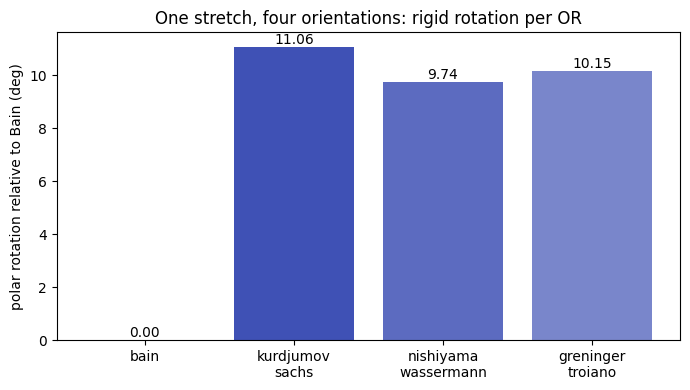

In [6]:
relationships = {
    "bain": bain,
    "kurdjumov_sachs": ks,
    "nishiyama_wassermann":
        OrientationRelationship.from_nishiyama_wassermann_correspondence(
            parent_phase=austenite, child_phase=martensite),
    "greninger_troiano":
        OrientationRelationship.from_greninger_troiano_correspondence(
            parent_phase=austenite, child_phase=martensite),
}
names, angles = [], []
for name, relationship in relationships.items():
    entry = relationship.deformation_gradient()
    names.append(name.replace("_", "\n"))
    angles.append(entry.polar_rotation_deg)
    stretches = np.round(entry.principal_stretches, 4)
    print(f"{name:22s} stretches {stretches}  "
          f"polar rotation {entry.polar_rotation_deg:6.2f} deg")

fig, ax = plt.subplots(figsize=(7.0, 4.0))
bars = ax.bar(names, angles,
              color=["#00897b", "#3f51b5", "#5c6bc0", "#7986cb"])
ax.bar_label(bars, fmt="%.2f")
ax.set_ylabel("polar rotation relative to Bain (deg)")
ax.set_title("One stretch, four orientations: rigid rotation per OR")
fig.tight_layout()


## The Burgers family: hcp on bcc {110}

The same doctrine covers hexagonal transformations. The Burgers
relationship $(0001)_{\mathrm{hcp}} \parallel \{110\}_{\mathrm{bcc}}$,
$\langle 11\bar 2 0\rangle \parallel \langle 111\rangle$ and its
relatives differ by small rotations on (or off) the shared interface
plane:

![Burgers family basal alignment](../../_static/or/burgers_family_basal_alignment.svg)

Below, the overlay is computed from the *actual* Burgers rotation: bcc
atoms lying in the (110) plane are projected onto it together with the
hcp basal net mapped through $R^{\mathsf T}$. The close-packed rows
coincide; the remaining mismatch is what interface dislocations must
accommodate.


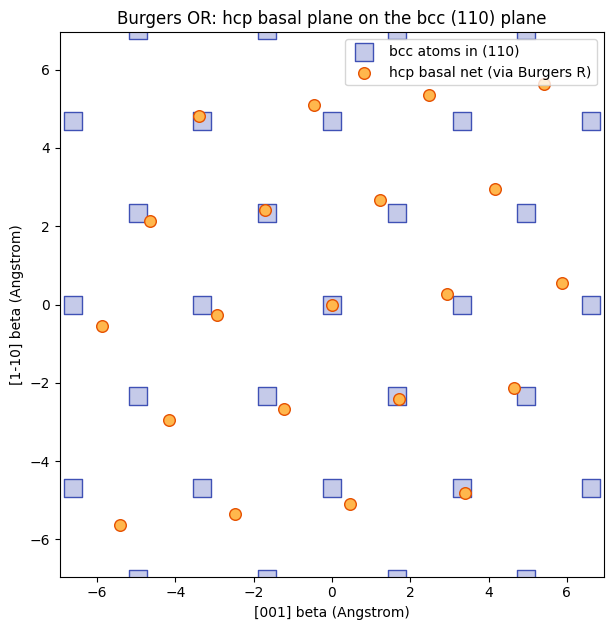

In [7]:
hex_frame = ReferenceFrame(
    "alpha_crystal", FrameDomain.CRYSTAL, ("a", "b", "c"), Handedness.RIGHT
)
a_b, a_h, c_h = 3.31, 2.95, 4.68   # beta-Ti bcc / alpha-Ti hcp (Angstrom)
beta = Phase(
    "beta_ti",
    lattice=Lattice(a_b, a_b, a_b, 90.0, 90.0, 90.0,
                    crystal_frame=austenite.crystal_frame),
    symmetry=austenite.symmetry,
    crystal_frame=austenite.crystal_frame,
)
alpha = Phase(
    "alpha_ti",
    lattice=Lattice(a_h, a_h, c_h, 90.0, 90.0, 120.0,
                    crystal_frame=hex_frame),
    symmetry=SymmetrySpec.from_point_group("6/mmm", reference_frame=hex_frame),
    crystal_frame=hex_frame,
)
burgers = OrientationRelationship.from_burgers_correspondence(
    parent_phase=beta, child_phase=alpha
)
rotation = burgers.parent_to_child_rotation.as_matrix()

# orthonormal basis of the (110) bcc plane: e1 = [001], e2 = [1,-1,0]/sqrt2
e1 = np.array([0.0, 0.0, 1.0])
e2 = np.array([1.0, -1.0, 0.0]) / np.sqrt(2.0)

# bcc atoms (corners + body centers) in the (110) plane through origin
span = np.arange(-2, 3)
bcc_points = []
for i in span:
    for j in span:
        for k in span:
            for offset in (np.zeros(3), np.full(3, 0.5)):
                site = (np.array([i, j, k], float) + offset) * a_b
                if abs(site[0] + site[1]) < 1e-9:
                    bcc_points.append([site @ e1, site @ e2])
bcc_points = np.array(bcc_points)

# hcp basal net mapped into the bcc crystal frame via R^T
basal = []
a1 = alpha.lattice.direct_basis().matrix[:, 0]
a2 = alpha.lattice.direct_basis().matrix[:, 1]
for m in span:
    for n in span:
        site = rotation.T @ (m * a1 + n * a2)
        basal.append([site @ e1, site @ e2])
basal = np.array(basal)

fig, ax = plt.subplots(figsize=(7.4, 6.4))
ax.scatter(bcc_points[:, 0], bcc_points[:, 1], s=170, marker="s",
           facecolor="#c5cae9", edgecolor="#3f51b5",
           label="bcc atoms in (110)")
ax.scatter(basal[:, 0], basal[:, 1], s=70,
           facecolor="#ffb74d", edgecolor="#e65100",
           label="hcp basal net (via Burgers R)")
limit = 2.1 * a_b
ax.set_xlim(-limit, limit), ax.set_ylim(-limit, limit)
ax.set_aspect("equal")
ax.set_xlabel("[001] beta (Angstrom)")
ax.set_ylabel("[1-10] beta (Angstrom)")
ax.legend(loc="upper right")
ax.set_title("Burgers OR: hcp basal plane on the bcc (110) plane")
fig.tight_layout()


The near-coincidence of the two nets along one close-packed row - and
the growing mismatch away from it - is the geometric content of the
Burgers relationship. Notebook 20 turns to the catalogs (including
Pitsch-Schrader, Potter, and the ferrite-cementite pair) and the
experimental identification/reconstruction pipeline.
